# ***Modeling complex time series (ARMA model)***

 we will examine the autoregressive moving average process,
ARMA(p,q), where p denotes the order of the autoregressive portion and q
denotes the order of the moving average portion. Furthermore, using the
ACF and PACF plots to determine the orders q and p, respectively, becomes
difficult, as both plots will show either a slowly decaying or sinusoidal
pattern. Thus, we will define a general modeling procedure that will allow us
to model such complex time series. This procedure involves model selection
using the Akaike information criterion (AIC), which will determine the
optimal combination of p and q for our series. Then we must evaluate the
model’s validity using residual analysis by studying the correlogram, Q-Q
plot, and density plot of the model’s residuals to assess if they closely
resemble white noise. If that is the case, we can move on to forecasting our
time series using the ARMA(p,q) model.

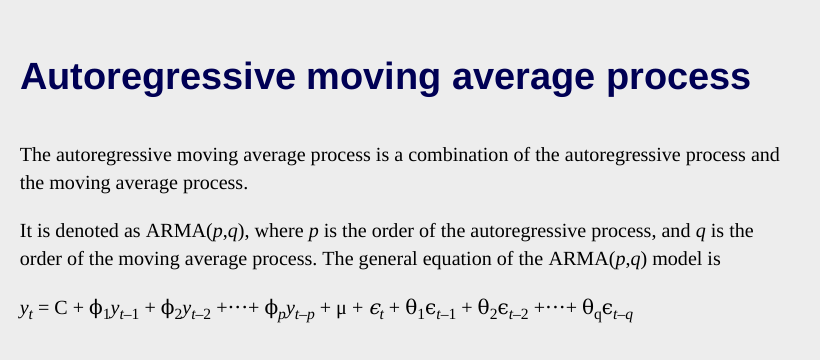
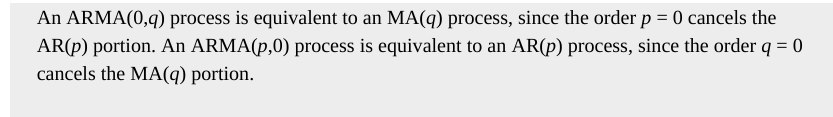

## **Identifying a stationary ARMA process**

### Now that we’ve defined the autoregressive moving average process and seen how the orders p and q affect the model’s equation, we need to determine how to identify such an underlying process in a given time series.We’ll extend the steps that we defined in AR model to include the final possibility that we have an ARMA(p,q) process, as shown in figure.

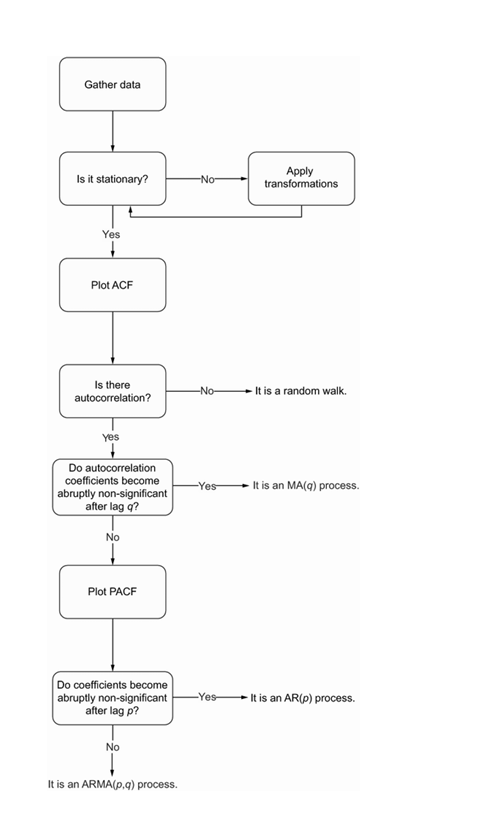

Steps to identify a random walk, a moving average process
MA(q), an autoregressive process AR(p), and an autoregressive moving
average process ARMA(p, q)

### **you’ll notice that if neither of the ACF and PACF plots shows a clear cutoff between significant and non-significant coefficients, then we have an ARMA(p,q) process. To verify that, let’s simulate our own ARMA process.**

### *We will simulate an ARMA(1,1) process. This is an combination of MA(1) and AR(1) process.Specifically, we will simulate the ARMA(1,1) process defined in euqtion. here c and mean are both 0.*
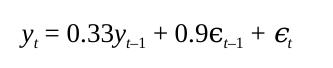

The objective of this simulation is to demonstrate that we cannot use the
ACF plot to identify the order q of an ARMA(p,q) process, which in this
case is 1, nor can we use the PACF plot to identify the order p of an
ARMA(p,q) process, which in this case is 1 also.

In [89]:
# importing libraries and prerequisite
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.tsa.stattools as sts
import statsmodels.graphics.tsaplots as sgt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [90]:
np.random.seed(42)
ar1=np.array([1,-0.33])
ma1=np.array([1,0.9])
ARMA_1_1=ArmaProcess(ar1,ma1).generate_sample(nsample=1000)

### *With our simulated data ready, we can move on to the next step and verify whether our process is stationary or not.*

In [91]:
sts.adfuller(ARMA_1_1)

(np.float64(-6.429878682042691),
 np.float64(1.7078466680096923e-08),
 20,
 979,
 {'1%': np.float64(-3.4370471695043037),
  '5%': np.float64(-2.8644967585264784),
  '10%': np.float64(-2.5683443301882956)},
 np.float64(2760.1171729466205))

### As we can see that p-value is less than 0.05 and test statistic also less than the table value so our process is stationary

### ***Following the steps outlined in figure, we’ll plot the ACF and see if we can infer the order of the moving average portion of our simulated ARMA(1,1) process.***

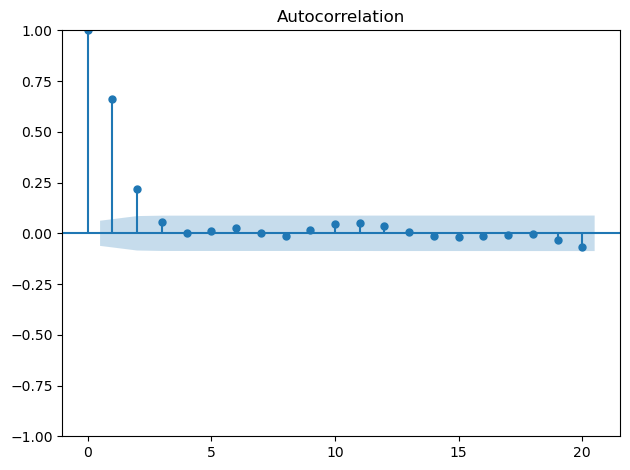

In [92]:
sgt.plot_acf(ARMA_1_1,lags=20)
plt.tight_layout()

#### **ACF plot of our simulated ARMA(1,1) process. Notice the sinusoidal pattern on the plot, meaning that an AR(p) process is in play.Also, the last significant coefficient is at lag 2, which suggests that q = 2.However, we know that we simulated an ARMA(1,1) process, so q must be equal to 1! Therefore, the ACF plot cannot be used to infer the order q of an ARMA(p, q) process.**

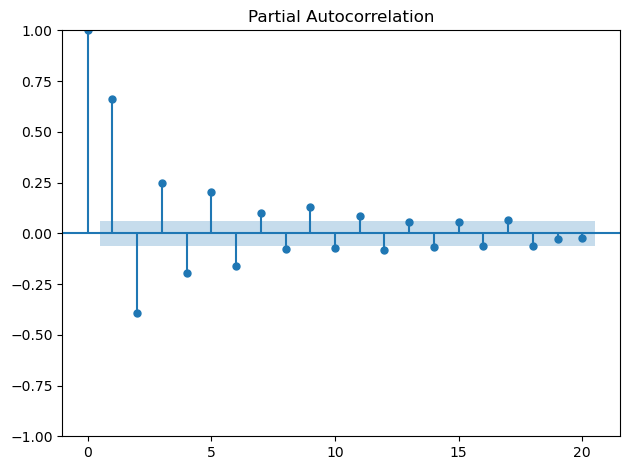

In [93]:
sgt.plot_pacf(ARMA_1_1,lags=20)
plt.tight_layout()

#### **PACF plot of our simulated ARMA(1,1) process. Again, we have a sinusoidal pattern with no clear cutoff between significant and non-significant coefficients. From this plot, we cannot infer that p = 1 in our simulated ARMA(1,1) process, meaning that we cannot determine the order p of an ARMA(p, q) process using a PACF plot.**

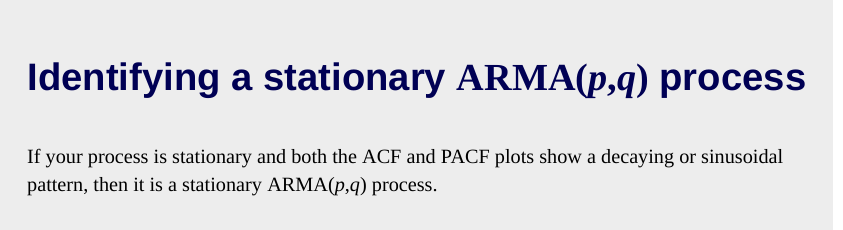

We know that determining the order of our process is key in modeling and
forecasting, since the order will dictate how many parameters must be
included in our model. Since the ACF and PACF plots are not useful in the
case of an ARMA(p,q) process, we must thus devise a general modeling
procedure that will allow us to find the appropriate combination of (p,q) for
our model.

## ***Devising a general modeling procedure.***

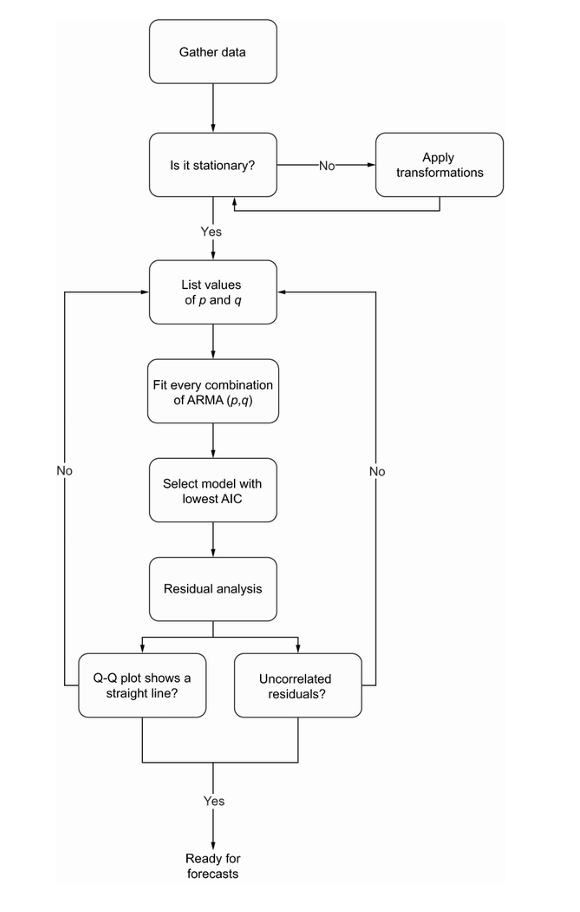

#### **General modeling procedure for an ARMA(p, q) process. The first steps are to gather the data, test for stationarity, and apply transformations accordingly. Then we define a list of possible values for p and q. We then fit every combination of ARMA(p, q) to our data and select the model with the lowest AIC. Then we perform the residual analysis by looking at the Q-Q plot and the residual correlogram. If they approach that of white noise, the model can be used for forecasts. Otherwise, we must try different values for p and q.**

## ***Understanding the Akaike information criterion (AIC)***

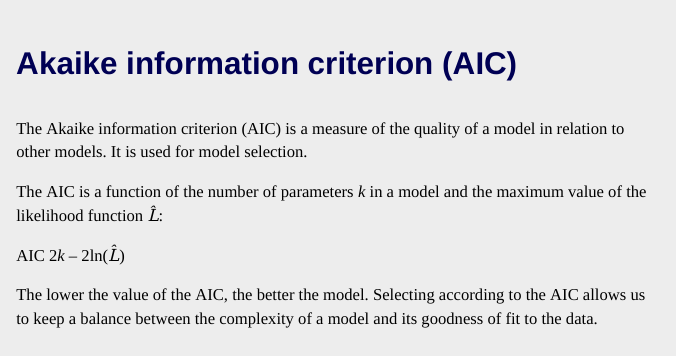

**AIC = Akaike Information Criterion
It is a score that helps you pick the best model — always pick the model with the lowest AIC.**
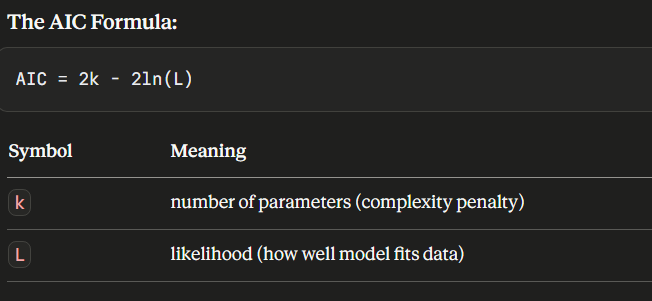
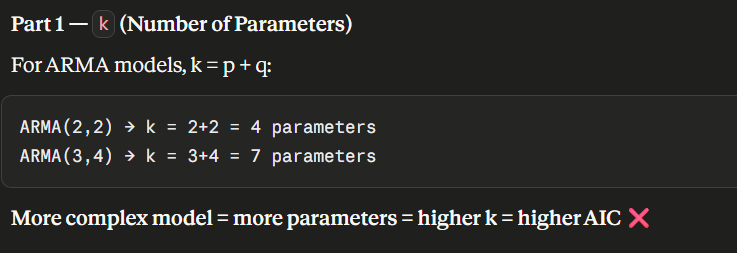
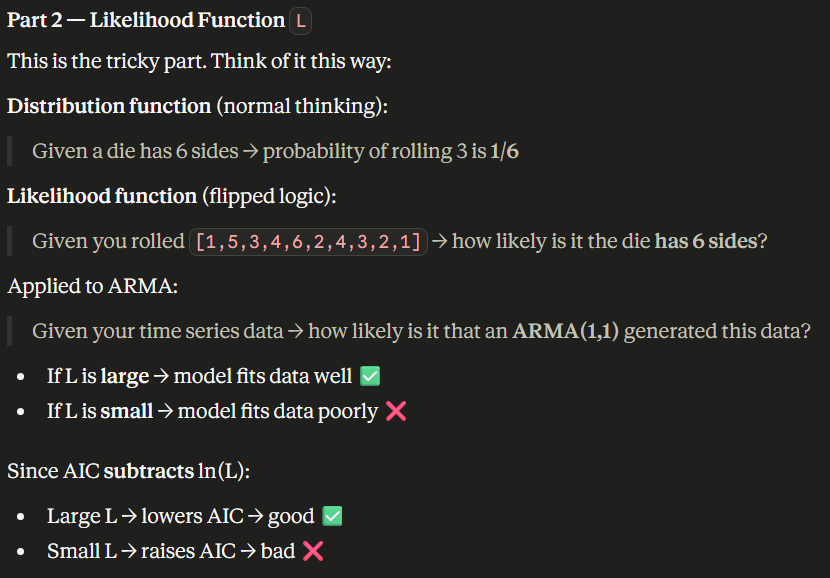

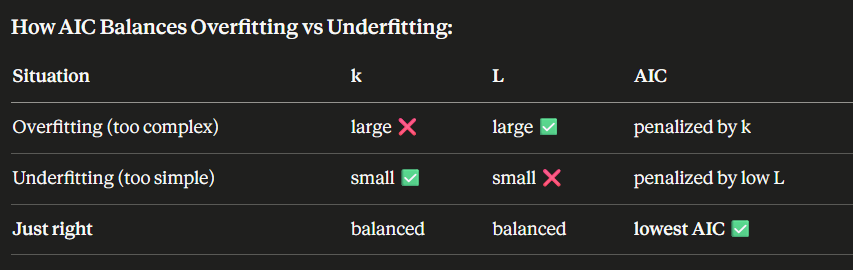
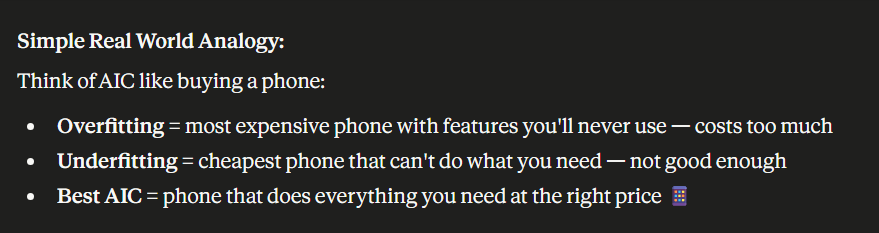

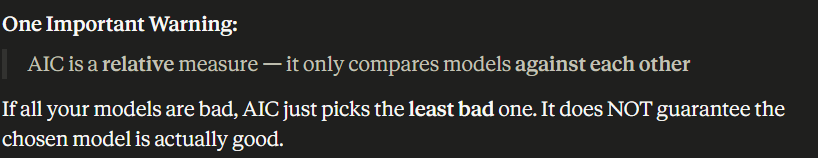

## **Selecting a model using the AIC**
**We’ll now cover the steps of the general modeling procedure outlined in
figure using our simulated ARMA(1,1) process.**

we tested for stationarity and concluded that our simulated
process is already stationary. Therefore, we can move on to defining a list of
possible values for p and q. While we know the values of both orders from
the simulation, let’s consider the following steps as a demonstration that the
general modeling procedure works.
We will allow the values of p and q to vary from 0 to 3. Note that this range
is arbitrary, and you may try a larger range of values if you wish. We will
create a list of all possible combinations of (p,q), using the product
function from itertools. Since there four possible values for p and q, this
will generate a list of 16 unique combinations of (p,q)

In [94]:
from itertools import product 
ps = range(0, 4, 1)                  
qs = range(0, 4, 1)                  
order_list = list(product(ps, qs)) # gives all the 16 combination of ps and qs in a list
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [95]:
for (p, q) in order_list:
    model = SARIMAX(ARMA_1_1, order=(p, 0, q)).fit()
    print(p, q, model.aic)

0 0 3780.418415971244
0 1 2891.869245214564
0 2 2812.840730187356
0 3 2803.666793045546
1 0 3207.291260644752
1 1 2801.407785099322
1 2 2802.9677623848766
1 3 2804.5240273156714
2 0 3042.6277869473342
2 1 2802.906069544806
2 2 2804.8222818295026
2 3 2806.1753800641095
3 0 2981.6439105552254
3 1 2804.588567202328
3 2 2806.8949296085584
3 3 2806.2672661882248


In [96]:
# more profession code of the above code does the same thing
from typing import Union
from tqdm.notebook import tqdm_notebook
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [97]:
result_df = optimize_ARMA(ARMA_1_1, order_list)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(2, 3)",2806.175380
8,"(3, 3)",2806.267266
9,"(3, 2)",2806.894930


**Resulting DataFrame from fitting all ARMA(p, q) models to
the simulated ARMA(1,1) data. We can see that the model with the
lowest AIC corresponds to an ARMA(1,1) model, meaning that we
successfully identified the order of our simulated data.**

As mentioned in the previous section, the AIC is a measure of relative
quality. Here we can say that an ARMA(1,1) model is the best model
relative to all other models that we fit to our data. Now we need an absolute
measure of the model’s quality. This brings us to the next step of our
modeling procedure, which is residual analysis

## **Understanding residual analysis**

=== ARMA MODELING PROCEDURE ===

STEP 1 — Check Stationarity
- If not stationary → apply differencing or log transformation
- If stationary → proceed

STEP 2 — Create order list
- List all (p,q) combinations to try
- Example: ps = range(0,4), qs = range(0,4) → 16 combinations

STEP 3 — Fit all ARMA(p,q) models and compare AIC
- Lower AIC = better model
- Select model with lowest AIC

STEP 4 — Residual Analysis
Residuals = Actual values - Predicted values
In a perfect model → residuals = white noise (random, uncorrelated)

Two checks:
1. Q-Q Plot (Qualitative check)
   - If straight diagonal line → residuals are normally distributed ✅
   - If curved → residuals not normal ❌

2. Ljung-Box Test (Quantitative check)
   - If residuals are uncorrelated → model is good ✅
   - If residuals are correlated → model missed patterns ❌

STEP 5 — Decision
- Both checks pass → Ready for forecasting ✅
- Any check fails → Go back to Step 2, try different (p,q) ❌

KEY POINT:
- AIC = relative quality (best among fitted models)
- Residual analysis = absolute quality (is the model actually good?)
- Residuals must be: uncorrelated + normally distributed

## **QUALITATIVE ANALYSIS: STUDYING THE Q-Q PLOT**

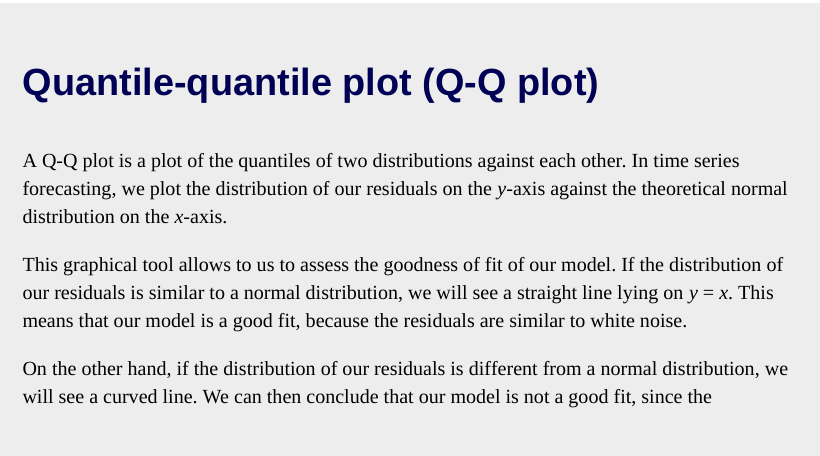
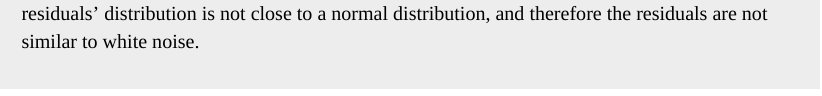

=== Q-Q PLOT (QUALITATIVE RESIDUAL ANALYSIS) ===

WHAT IS IT?
- Q-Q = Quantile-Quantile plot
- Graphical tool to check if residuals are normally distributed
- Compares residuals distribution vs normal distribution

HOW IT IS CONSTRUCTED?
- Y-axis → quantiles of model residuals
- X-axis → quantiles of normal distribution
- Result → scatterplot

WHY NORMAL DISTRIBUTION?
- Residuals should behave like white noise
- White noise is normally distributed
- So residuals ≈ normal distribution = good model

TWO POSSIBLE OUTCOMES:

1. GOOD MODEL ✅
   - Points form a straight line on y = x
   - Residuals are normally distributed
   - Model is a good fit → proceed to quantitative analysis

2. BAD MODEL ❌
   - Points curve/depart from y = x
   - Residuals are NOT normally distributed
   - Model is NOT a good fit
   - Go back → try different (p,q) combinations

REMEMBER:
- Straight line on y = x → GOOD ✅
- Curved line away from y = x → BAD ❌

### ***QUANTITATIVE ANALYSIS: APPLYING THE LJUNG-BOX TEST***

**Once we have analyzed the Q-Q plot and determined that our residuals are
approximately normally distributed, we can then apply the Ljung-Box test to
demonstrate that the residuals are uncorrelated. Remember that a good
model has residuals that are similar to white noise, so the residuals should be
normally distributed and uncorrelated.
The Ljung-Box test is a statistical test that tests if the autocorrelation of a
group of data is significantly different from 0. In our case, we will apply the
Ljung-Box test to the model’s residuals to assess whether they are correlated
or not. The null hypothesis states that the data is independently distributed,
meaning that there is no autocorrelation**

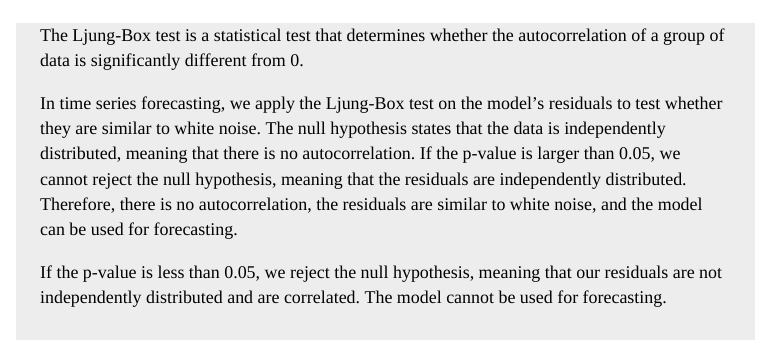

## **Performing residual analysis**

**We know that our ARMA(1,1) model must be good, since we simulated an
ARMA(1,1) process, but this section will demonstrate that our modeling
procedure works. We are not likely to be modeling and forecasting simulated
data in a business context, so it is important to cover the entire modeling
procedure on a known process first, to convince ourselves that it works,
before applying it on real-life data.**

**To perform residual analysis, we need to fit our model and store the residuals
in a variable for easy access. Using statsmodels, we will first define an
ARMA(1,1) model before fitting it to our simulated data. Then we can
access the residuals with the resid property.**

In [98]:
model = SARIMAX(ARMA_1_1, order=(1,0,1), simple_differencing=False)
model_fit = model.fit(disp=False)
residuals = model_fit.resid

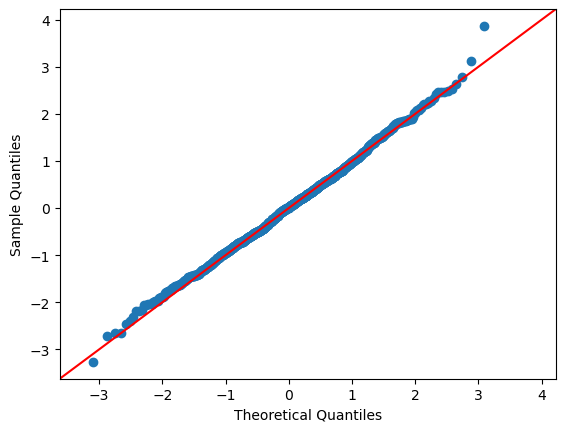

In [99]:
# Q-Q plot 
from statsmodels.graphics.gofplots import qqplot
qqplot(residuals, line='45');

*Q-Q plot of our ARMA(1,1) residuals. You can see a thick
straight line lying on y = x. This means that our residuals are normally
distributed, just like white noise.*

***We’ll extend our qualitative analysis by using the plot_diagnostics
method. This generates a figure containing four different plots, including a
Q-Q plot.***

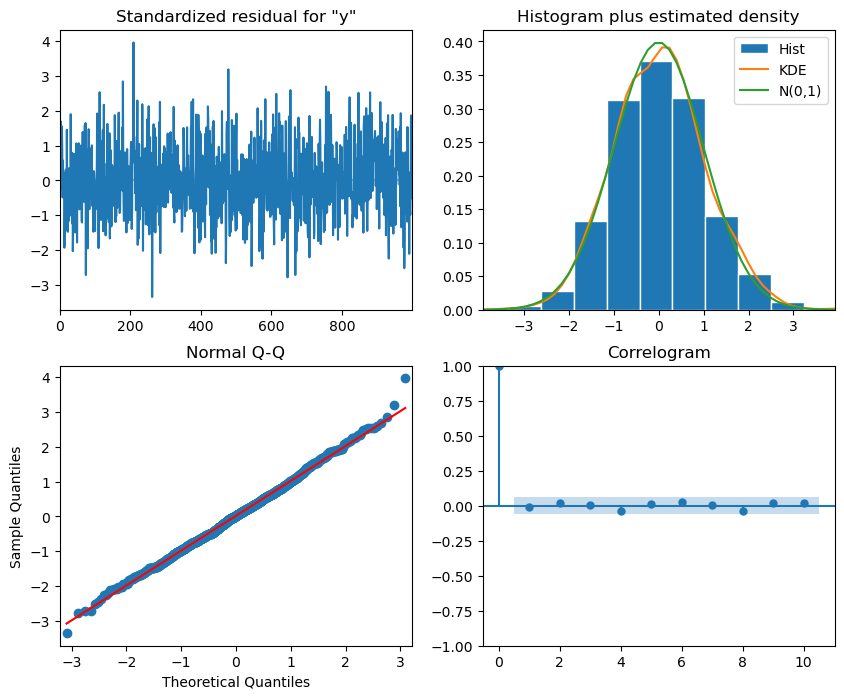

In [100]:
model_fit.plot_diagnostics(figsize=(10, 8));

*Model diagnostics from statsmodels. The top-left plot
displays the residuals, the histogram of the residuals is at the top right,
the Q-Q plot of the residuals is at the bottom left, and the bottom right
shows the ACF plot of the residuals.*

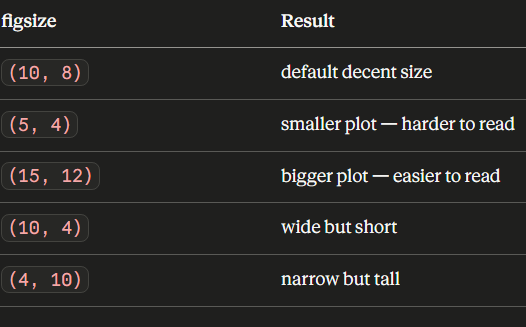

### **The final step in residual analysis is applying the Ljung-Box test. This allows us to quantitatively assess whether our residuals are indeed uncorrelated**

In [101]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(residuals, np.arange(1, 11, 1)) 

,lb_stat,lb_pvalue
1,0.030706,0.860897
2,0.528021,0.767966
3,0.540904,0.909817
4,2.079774,0.721089
5,2.271897,0.810385
6,2.896262,0.821750
7,2.900378,0.894063
8,4.418799,0.817501
9,4.787567,0.852419
10,5.246805,0.874093


The resulting list of p-values shows that each is above 0.05. Therefore, at
each lag, the null hypothesis cannot be rejected, meaning that the residuals
are independently distributed and uncorrelated.
We can conclude from our analysis that the residuals are similar to white
noise. The Q-Q plot showed a straight line, meaning that the residuals are
normally distributed. Furthermore, the Ljung-Box test shows that the
residuals are uncorrelated, just like white noise. Thus, the residuals are
completely random, meaning that we have a model that fits our data well.

## **Applying the general modeling procedure on bandwidth dataset**


In [150]:
# GATHERING AND IMPORTING DATA
df=pd.read_csv('bandwidth.csv')
df.head(3)

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019


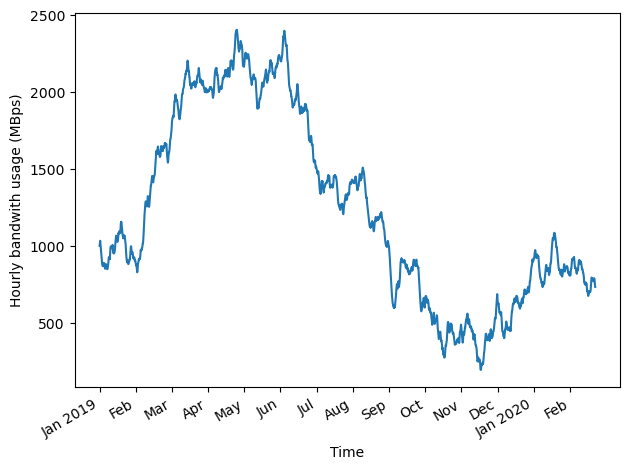

In [151]:
# visualizing our data
fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

Hourly bandwidth usage in a data center since January 1,
2019. The dataset contains 10,000 points.

In [105]:
# checking if the data is stationary or not 
sts.adfuller(df['hourly_bandwidth'])

(np.float64(-0.8714653199452812),
 np.float64(0.7972240255014527),
 6,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28347.577478302363))

#### **as we can see the p-value is > 0.05 and test-statistic > table value implies that the our data is not stationary**

In [110]:
# Applying transformation
bd_diff=np.diff(df.hourly_bandwidth,n=1)

array([ 0.47269411,  1.07661104,  2.65609895, ..., -2.84823217,
       -2.49835551, -1.36959095])

In [111]:
# Again applying ADfuller test
sts.adfuller(bd_diff)

(np.float64(-20.694853863789014),
 0.0,
 5,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28344.57207305265))

#### **As we can see that the p-value < 0.05 and test-statistic < table value so our transformation is stationary**

### **now we start modeling our stationary process using ARMA(p,q) model.we will first split aur data into test and train**

Here we’ll
keep the last 7 days of data for the test set. Since our forecasts are for the
next 2 hours, the test set thus contains 84 periods of 2 hours on which to
evaluate our models’ performance, since 7 days of hourly data totals 168
hours.

In [114]:
df_diff=pd.DataFrame({'bd_diff':bd_diff})
train=df_diff[:-168]
test=df_diff[-168:]
print(len(train))
print(len(test))

9831
168


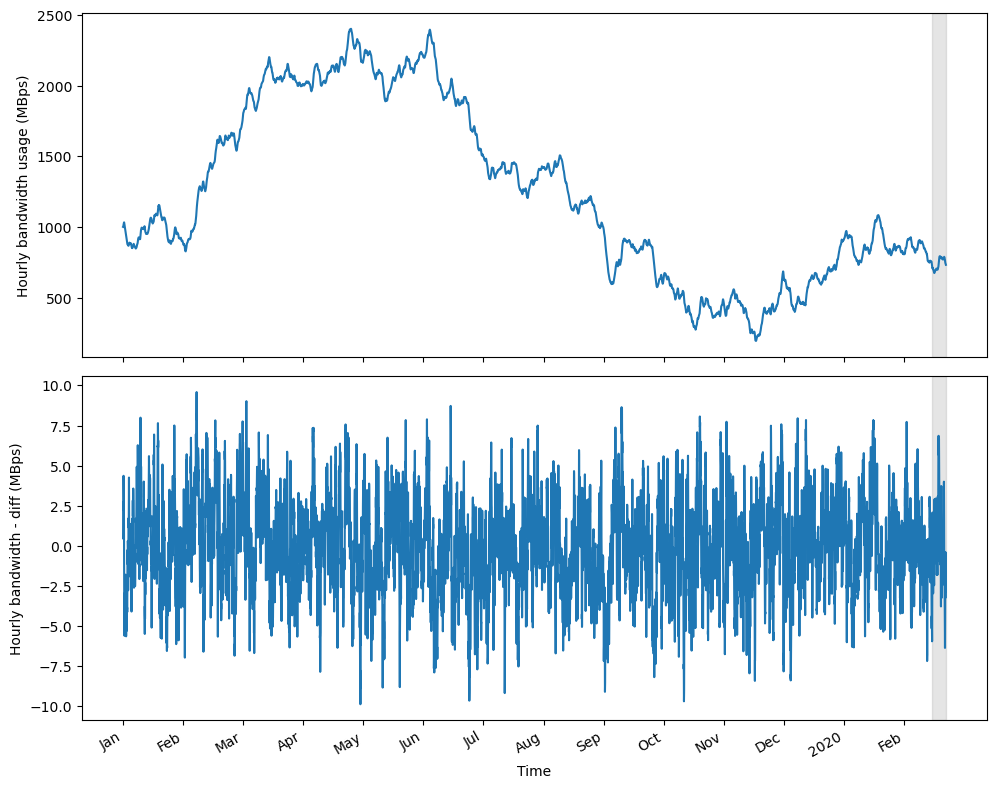

In [116]:
# visulizing our train and test data
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['hourly_bandwidth'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Hourly bandwidth usage (MBps)')
ax1.axvspan(9831, 10000, color='#808080', alpha=0.2)

ax2.plot(df_diff['bd_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Hourly bandwidth - diff (MBps)')
ax2.axvspan(9830, 9999, color='#808080', alpha=0.2)

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

**Train and test sets for the original and differenced series**

### **Now our train model is ready we can try finding ARMA order withe help of the function we derived earlier for findiang lowest AIC.**

In [117]:
ps = range(0, 4, 1)                   
qs = range(0, 4, 1)                   
order_list = list(product(ps, qs)) 

In [124]:
for (p,q) in order_list:
     model = SARIMAX(train, order=(p, 0, q)).fit()
     print(p,q,model.aic)

0 0 49035.184224029945
0 1 39402.26952340243
0 2 33531.17928371294
0 3 31355.80214098027
1 0 28941.05698349204
1 1 28172.51004430835
1 2 28051.351401016098
1 3 28003.349549512306
2 0 28098.4076635046
2 1 28097.25076636965
2 2 27991.603597914094
2 3 27991.287508605063
3 0 28095.61818585036
3 1 28071.155496050083
3 2 27991.063878992303
3 3 27993.416924440167


In [125]:
# or use the function
result_df = optimize_ARMA(train, order_list)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",AIC
0,"(3, 2)",27991.063879
1,"(2, 3)",27991.287509
2,"(2, 2)",27991.603598
3,"(3, 3)",27993.416924
4,"(1, 3)",28003.349550
5,"(1, 2)",28051.351401
6,"(3, 1)",28071.155496
7,"(3, 0)",28095.618186
8,"(2, 1)",28097.250766
9,"(2, 0)",28098.407664


#### *A DataFrame ordered by ascending value of AIC, resulting from fitting different ARMA(p, q) models on the differenced bandwidth dataset. Notice how the first three models all have an AIC value of 27,991.*

#### ***To perform the residual analysis, we’ll fit the ARMA(2,2) model on our training set. Then we’ll use the plot_diagnostics method to study the QQ plot, as well as the other accompanying plots***

In [126]:
model = SARIMAX(train['bd_diff'], order=(2,0,2), simple_differencing=False)
model_fit = model.fit(disp=False)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                bd_diff   No. Observations:                 9831
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -13990.802
Date:                Sat, 16 May 2026   AIC                          27991.604
Time:                        16:08:33   BIC                          28027.570
Sample:                             0   HQIC                         28003.788
                               - 9831                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.052      6.765      0.000       0.248       0.450
ar.L2          0.4743      0.047     10.000      0.000       0.381       0.567
ma.L1          0.8667      0.050     17.249      0.0

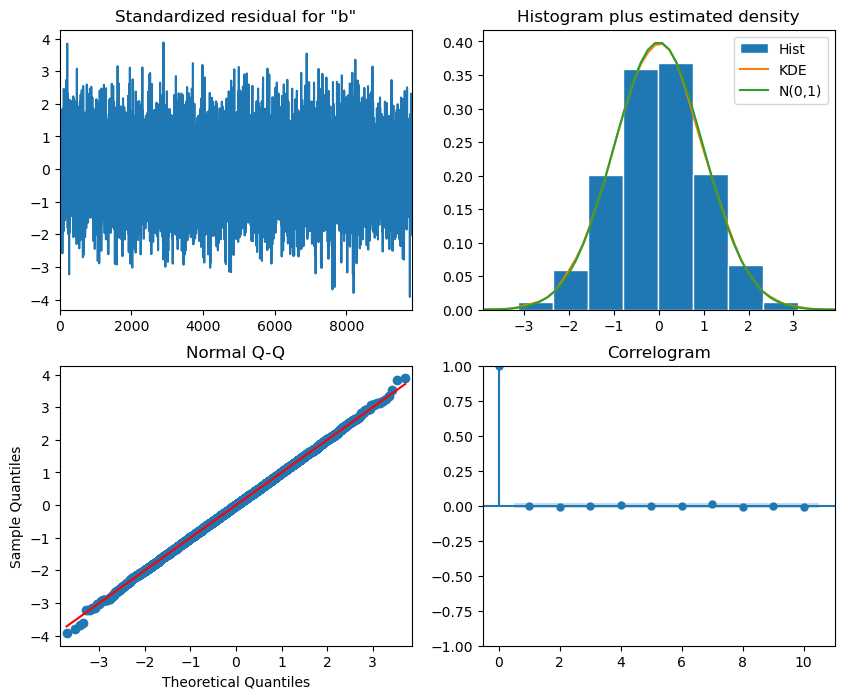

In [127]:
model_fit.plot_diagnostics(figsize=(10, 8));

### *Model diagnostics from statsmodels. The top-left plot displays the residuals, the histogram of the residuals is at the top right,the Q-Q plot of the residuals is at the bottom left, and the bottom right shows the ACF plot of the residuals.*

 you can see that the top-left plot shows no trend, and the mean
seems constant over time, meaning that our residuals are likely stationary.
The top right displays a density plot with a shape similar to that of a normal
distribution. The Q-Q plot at the bottom left shows a thick straight line that
is very close to y = x. Finally, the ACF plot at the bottom right shows no
autocorrelation after lag 0. Thus, figure 6.18 indicates that our residuals
clearly resemble white noise, since they are normally distributed and
uncorrelated.
Our last step is to run the Ljung-Box test on the residuals for the first 10
lags. If the returned p-values exceed 0.05, we cannot reject the null
hypothesis, which means that our residuals are uncorrelated and
independently distributed, just like white noise

In [132]:
residuals = model_fit.resid
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,0.042190,0.837257
2,0.418364,0.811247
3,0.520271,0.914416
4,0.850554,0.931545
5,0.850841,0.973678
6,1.111754,0.981019
7,2.124864,0.952607
8,3.230558,0.919067
9,3.248662,0.953615
10,3.588289,0.964015


The returned p-values all exceed 0.05. Therefore, we can conclude that our
residuals are indeed uncorrelated. Our ARMA(2,2) model has passed all the
checks on the residual analysis, and we are ready to use this model to
forecast bandwidth usage.

## **Forecasting bandwidth usage**

In [133]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(2,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA

In [134]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_ARMA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'ARMA')

test.loc[:, 'pred_mean'] = pred_mean
test.loc[:, 'pred_last_value'] = pred_last_value
test.loc[:, 'pred_ARMA'] = pred_ARMA

test.head()

,bd_diff,pred_mean,pred_last_value,pred_ARMA
9831,-5.943995,-0.028214,-5.791207,-5.460661
9832,-5.865194,-0.028214,-5.791207,-4.890626
9833,-3.197066,-0.029410,-5.865194,-5.335905
9834,-1.090197,-0.029410,-5.865194,-4.751731
9835,0.665291,-0.029840,-1.090197,-0.375596


## **VISUALIZING THE DATA**

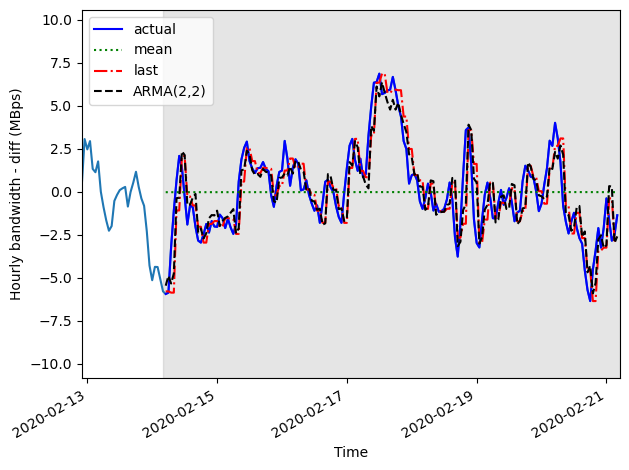

In [137]:
fig, ax = plt.subplots()

ax.plot(df_diff['bd_diff'])
ax.plot(test['bd_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_ARMA'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwidth - diff (MBps)')

ax.axvspan(9830, 9999, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

**Forecasts of the differenced hourly bandwidth usage using
the mean, the last known value, and an ARMA(2,2) model. You can see
how the ARMA(2,2) forecasts and last known value forecasts almost
coincide with the actual values of the test set.**

 you can see that the ARMA(2,2) forecasts, shown as a dashed
line, almost coincide with the actual values of the test set. The same can be
said of the forecasts from the last known value method, shown as a dashed
and dotted line. Of course, the forecasts using the mean, shown as a dotted
line, are completely flat over the testing period.
We’ll now measure the mean squared error (MSE) to evaluate the
performance of each model. The model with the lowest MSE is the best
performing model.

In [140]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse_mean = mean_squared_error(test['bd_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['bd_diff'], test['pred_last_value'])
mse_ARMA = mean_squared_error(test['bd_diff'], test['pred_ARMA'])

print(mse_mean, mse_last, mse_ARMA)

6.306526957989325 2.2297582947733656 1.769046211364524


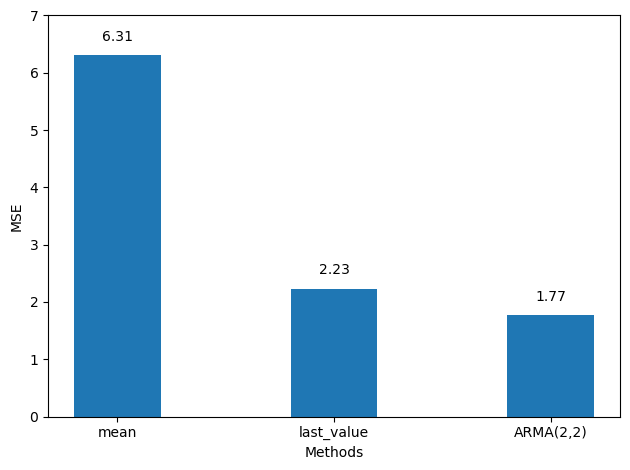

In [141]:
# bar graph
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'ARMA(2,2)']
y = [mse_mean, mse_last, mse_ARMA] 

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 7)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

**The final step is to reverse the transformation of our forecast in order to
bring it to the same scale as our original data. Remember that we differenced
the original data to make it stationary. The ARMA(2,2) model was then
applied on the stationary dataset and produced forecasts that are differenced.**

In [148]:
df['pred_bandwidth'] = pd.Series()
df['pred_bandwidth'][9832:] = df['hourly_bandwidth'].iloc[9832] + test['pred_ARMA'].cumsum()
df.tail()

,hourly_bandwidth,pred_bandwidth
9995,740.546059,721.377109
9996,738.906228,721.70246
9997,736.057995,721.996748
9998,733.559640,719.020898
9999,732.190049,716.423855


## **VISUALIZING OUR ORIGINAL DATA**

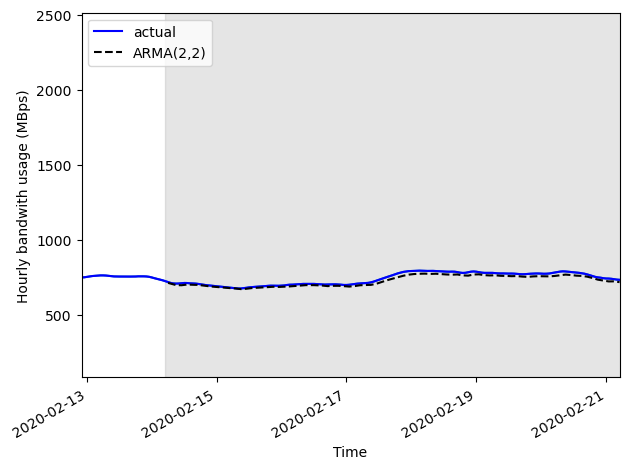

In [149]:
fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.plot(df['hourly_bandwidth'], 'b-', label='actual')
ax.plot(df['pred_bandwidth'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

ax.axvspan(9831, 10000, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

**Undifferenced predictions of hourly bandwidth usage.
Notice how the dashed line representing our predictions almost
coincides with the solid line representing the actual values. This means
that our predictions are very close to the actual values, indicating a
performant model.**